In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import numpy as np

In [2]:
df = pd.read_parquet('../data_2024_otimizado.parquet')

In [5]:
print(df.columns)

Index(['1.a.1_faixa_idade', '1.b_genero', '1.d_pcd',
       '1.e_experiencia_profissional_prejudicada', '2.g_nivel',
       '2.h_faixa_salarial', 'Amarela', 'Branca', 'Parda', 'Preta'],
      dtype='str')


In [7]:
mapeamento = {
    '1.a.1_faixa_idade' : 'Idade',
    '1.b_genero' : 'Gênero',
    '1.d_pcd' : 'PCD',
    '1.e_experiencia_profissional_prejudicada' : 'Experiência Profissional Prejudicada',
    '2.g_nivel' : 'Nível',
    '2.h_faixa_salarial' : 'Faixa Salarial',
    'Amarela' : 'Amarela',
    'Branca' : 'Branca',
    'Parda' : 'Parda',
    'Preta' : 'Preta'
}

In [8]:
df_limpo = df[list(mapeamento.keys())].rename(columns=mapeamento)

In [6]:
df_limpo = df_limpo[df_limpo['Gênero'] != 'Prefiro não informar'].dropna()

In [9]:
print(f"Total de registros para análise: {len(df_limpo)}")
df_limpo.tail()

Total de registros para análise: 5217


,Idade,Gênero,PCD,Experiência Profissional Prejudicada,Nível,Faixa Salarial,Amarela,Branca,Parda,Preta
5212,8,True,False,False,-1,4,False,True,False,False
5213,8,False,False,False,2,3,False,True,False,False
5214,8,True,False,False,-1,-1,False,False,True,False
5215,8,False,False,True,-1,4,False,False,True,False
5216,8,True,False,False,-1,-1,False,False,True,False


In [9]:
ordem_salario = [
    'Menos de R$ 1.000/mês', 'de R$ 1.001/mês a R$ 2.000/mês', 
    'de R$ 2.001/mês a R$ 3.000/mês', 'de R$ 3.001/mês a R$ 4.000/mês',
    'de R$ 4.001/mês a R$ 6.000/mês', 'de R$ 6.001/mês a R$ 8.000/mês',
    'de R$ 8.001/mês a R$ 12.000/mês', 'de R$ 12.001/mês a R$ 16.000/mês',
    'de R$ 16.001/mês a R$ 20.000/mês', 'de R$ 20.001/mês a R$ 25.000/mês',
    'de R$ 25.001/mês a R$ 30.000/mês', 'de R$ 30.001/mês a R$ 40.000/mês',
    'Acima de R$ 40.001/mês'
]
ordem_nivel = ['Júnior', 'Pleno', 'Sênior']

In [10]:
mapa_salario = {label: i for i, label in enumerate(ordem_salario)}
mapa_nivel = {label: i for i, label in enumerate(ordem_nivel)}
mapa_genero = {'Masculino': 0, 'Feminino': 1, 'Outro': 2}

In [11]:
df_limpo['Salario_Num'] = df_limpo['Salário'].map(mapa_salario)
df_limpo['Nivel_Num'] = df_limpo['Nivel'].map(mapa_nivel)
df_limpo['Genero_Num'] = df_limpo['Gênero'].map(mapa_genero)

In [12]:
df_limpo = df_limpo.dropna(subset=['Salario_Num', 'Nivel_Num', 'Genero_Num'])

In [10]:
print(f"Dados prontos! Total de registros: {len(df_limpo)}")

Dados prontos! Total de registros: 5217


In [19]:
# 1. Definir Atributos (X) e Alvo (y)
X = df_limpo[['Genero_Num', 'Nivel_Num']]
y = df_limpo['Salario_Num']

# 2. Divisão 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Treinar Árvore de Decisão
modelo_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_tree.fit(X_train, y_train)

# --- AUDITORIA DE VIÉS ---
# Separar o grupo de teste para ver onde a IA erra mais
teste_mulheres = X_test[X_test['Genero_Num'] == 1]
teste_homens = X_test[X_test['Genero_Num'] == 0]
teste_outros = X_test[X_test['Genero_Num']== 2]

acc_mulheres = accuracy_score(y_test.loc[teste_mulheres.index], modelo_tree.predict(teste_mulheres))
acc_homens = accuracy_score(y_test.loc[teste_homens.index], modelo_tree.predict(teste_homens))
acc_outros = accuracy_score(y_test.loc[teste_outros.index], modelo_tree.predict(teste_outros))

print(f"📊 Acurácia em Mulheres: {acc_mulheres:.2%}")
print(f"📊 Acurácia em Homens: {acc_homens:.2%}")
print(f"Teste acurácia em outros: {acc_outros:.2%}")

if acc_homens > acc_mulheres:
    print(f"⚠️ Alerta: O modelo é {acc_homens - acc_mulheres:.2%} mais preciso para homens do que para mulheres.")

📊 Acurácia em Mulheres: 36.93%
📊 Acurácia em Homens: 29.03%
Teste acurácia em outros: 50.00%


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# =========================================================
# 1. PREPARAÇÃO E TREINO DO MODELO
# =========================================================
# Definir as pistas (X) incluindo a interseccionalidade e o alvo (y)
X_etnia = df[['1.b_genero', '2.g_nivel', 'Amarela', 'Branca', 'Parda', 'Preta']]
y = df['2.h_faixa_salarial']

# Dividir em dados de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_etnia, y, test_size=0.3, random_state=42)

# Criar e treinar o modelo (agora com o nome correto: modelo_tree_etnia)
modelo_tree_etnia = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_tree_etnia.fit(X_train, y_train)


# =========================================================
# 2. PARTE 1: ACURÁCIA GERAL POR GÉNERO
# =========================================================
print("--- 1. RESULTADOS GERAIS POR GÉNERO ---")
teste_homens = X_test[X_test['1.b_genero'] == 0]
teste_mulheres = X_test[X_test['1.b_genero'] == 1]

acc_homens = accuracy_score(y_test.loc[teste_homens.index], modelo_tree_etnia.predict(teste_homens))
acc_mulheres = accuracy_score(y_test.loc[teste_mulheres.index], modelo_tree_etnia.predict(teste_mulheres))

print(f"📊 Acurácia em Homens (Geral): {acc_homens:.2%}")
print(f"📊 Acurácia em Mulheres (Geral): {acc_mulheres:.2%}\n")


# =========================================================
# 3. PARTE 2: ACURÁCIA INTERSECCIONAL (GÉNERO + ETNIA)
# =========================================================
print("--- 2. RESULTADOS INTERSECCIONAIS (GÉNERO + ETNIA) ---")

# Filtros para Mulheres por Etnia
teste_m_brancas = X_test[(X_test['1.b_genero'] == 1) & (X_test['Branca'] == True)]
teste_m_pretas = X_test[(X_test['1.b_genero'] == 1) & (X_test['Preta'] == True)]
teste_m_pardas = X_test[(X_test['1.b_genero'] == 1) & (X_test['Parda'] == True)]
teste_m_amarelas = X_test[(X_test['1.b_genero'] == 1) & (X_test['Amarela'] == True)]

# Filtros para Homens por Etnia
teste_h_brancos = X_test[(X_test['1.b_genero'] == 0) & (X_test['Branca'] == True)]
teste_h_pretos = X_test[(X_test['1.b_genero'] == 0) & (X_test['Preta'] == True)]
teste_h_pardos = X_test[(X_test['1.b_genero'] == 0) & (X_test['Parda'] == True)]
teste_h_amarelos = X_test[(X_test['1.b_genero'] == 0) & (X_test['Amarela'] == True)]

# --- Impressão dos Resultados das Mulheres ---
print(">> GRUPO: MULHERES")
if len(teste_m_brancas) > 0: 
    print(f"   Brancas:  {accuracy_score(y_test.loc[teste_m_brancas.index], modelo_tree_etnia.predict(teste_m_brancas)):.2%} (Tamanho da amostra: {len(teste_m_brancas)})")
if len(teste_m_pretas) > 0: 
    print(f"   Pretas:   {accuracy_score(y_test.loc[teste_m_pretas.index], modelo_tree_etnia.predict(teste_m_pretas)):.2%} (Tamanho da amostra: {len(teste_m_pretas)})")
if len(teste_m_pardas) > 0: 
    print(f"   Pardas:   {accuracy_score(y_test.loc[teste_m_pardas.index], modelo_tree_etnia.predict(teste_m_pardas)):.2%} (Tamanho da amostra: {len(teste_m_pardas)})")
if len(teste_m_amarelas) > 0: 
    print(f"   Amarelas: {accuracy_score(y_test.loc[teste_m_amarelas.index], modelo_tree_etnia.predict(teste_m_amarelas)):.2%} (Tamanho da amostra: {len(teste_m_amarelas)})")

print("")

# --- Impressão dos Resultados dos Homens ---
print(">> GRUPO: HOMENS")
if len(teste_h_brancos) > 0: 
    print(f"   Brancos:  {accuracy_score(y_test.loc[teste_h_brancos.index], modelo_tree_etnia.predict(teste_h_brancos)):.2%} (Tamanho da amostra: {len(teste_h_brancos)})")
if len(teste_h_pretos) > 0: 
    print(f"   Pretos:   {accuracy_score(y_test.loc[teste_h_pretos.index], modelo_tree_etnia.predict(teste_h_pretos)):.2%} (Tamanho da amostra: {len(teste_h_pretos)})")
if len(teste_h_pardos) > 0: 
    print(f"   Pardos:   {accuracy_score(y_test.loc[teste_h_pardos.index], modelo_tree_etnia.predict(teste_h_pardos)):.2%} (Tamanho da amostra: {len(teste_h_pardos)})")
if len(teste_h_amarelos) > 0: 
    print(f"   Amarelos: {accuracy_score(y_test.loc[teste_h_amarelos.index], modelo_tree_etnia.predict(teste_h_amarelos)):.2%} (Tamanho da amostra: {len(teste_h_amarelos)})")

--- 1. RESULTADOS GERAIS POR GÉNERO ---
📊 Acurácia em Homens (Geral): 45.27%
📊 Acurácia em Mulheres (Geral): 50.79%

--- 2. RESULTADOS INTERSECCIONAIS (GÉNERO + ETNIA) ---
>> GRUPO: MULHERES
   Brancas:  47.04% (Tamanho da amostra: 253)
   Pretas:   45.45% (Tamanho da amostra: 22)
   Pardas:   61.96% (Tamanho da amostra: 92)
   Amarelas: 57.14% (Tamanho da amostra: 14)

>> GRUPO: HOMENS
   Brancos:  44.01% (Tamanho da amostra: 784)
   Pretos:   49.43% (Tamanho da amostra: 87)
   Pardos:   46.95% (Tamanho da amostra: 279)
   Amarelos: 54.17% (Tamanho da amostra: 24)


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# =========================================================
# 1. PREPARAÇÃO DO X COMPLETO (Variáveis Técnicas + Demográficas)
# =========================================================
# Selecionamos todas as pistas que influenciam o salário
X_bruto = df[[
    '1.a.1_faixa_idade',
    '1.b_genero',
    '1.d_pcd',
    '1.e_experiencia_profissional_prejudicada',
    '2.g_nivel',
    'Amarela',
    'Branca',
    'Parda',
    'Preta'
]]

# O get_dummies transforma colunas de texto (como a linguagem) em colunas numéricas automaticamente
X_completo = pd.get_dummies(X_bruto)

y = df['2.h_faixa_salarial']

# =========================================================
# 2. DIVISÃO 80/20 (80% Treino, 20% Teste)
# =========================================================
# test_size=0.2 garante a divisão exata que você queria!
X_train, X_test, y_train, y_test = train_test_split(X_completo, y, test_size=0.3, random_state=42)

# =========================================================
# 3. TREINAMENTO DO MODELO
# =========================================================
modelo_tree_completo = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_tree_completo.fit(X_train, y_train)


# =========================================================
# 4. AUDITORIA DE VIÉS (GÊNERO + ETNIA)
# =========================================================
print("--- RESULTADOS DO MODELO COMPLETO (80/20) ---")

# Filtros para Mulheres por Etnia
teste_m_brancas = X_test[(X_test['1.b_genero'] == 1) & (X_test['Branca'] == True)]
teste_m_pretas = X_test[(X_test['1.b_genero'] == 1) & (X_test['Preta'] == True)]
teste_m_pardas = X_test[(X_test['1.b_genero'] == 1) & (X_test['Parda'] == True)]
teste_m_amarelas = X_test[(X_test['1.b_genero'] == 1) & (X_test['Amarela'] == True)]

# Filtros para Homens por Etnia
teste_h_brancos = X_test[(X_test['1.b_genero'] == 0) & (X_test['Branca'] == True)]
teste_h_pretos = X_test[(X_test['1.b_genero'] == 0) & (X_test['Preta'] == True)]
teste_h_pardos = X_test[(X_test['1.b_genero'] == 0) & (X_test['Parda'] == True)]
teste_h_amarelos = X_test[(X_test['1.b_genero'] == 0) & (X_test['Amarela'] == True)]

# --- Impressão dos Resultados ---
print("\n>> GRUPO: MULHERES")
if len(teste_m_brancas) > 0: print(f"   Brancas:  {accuracy_score(y_test.loc[teste_m_brancas.index], modelo_tree_completo.predict(teste_m_brancas)):.2%} (Amostra: {len(teste_m_brancas)})")
if len(teste_m_pretas) > 0:  print(f"   Pretas:   {accuracy_score(y_test.loc[teste_m_pretas.index], modelo_tree_completo.predict(teste_m_pretas)):.2%} (Amostra: {len(teste_m_pretas)})")
if len(teste_m_pardas) > 0:  print(f"   Pardas:   {accuracy_score(y_test.loc[teste_m_pardas.index], modelo_tree_completo.predict(teste_m_pardas)):.2%} (Amostra: {len(teste_m_pardas)})")
if len(teste_m_amarelas) > 0: print(f"   Amarelas: {accuracy_score(y_test.loc[teste_m_amarelas.index], modelo_tree_completo.predict(teste_m_amarelas)):.2%} (Amostra: {len(teste_m_amarelas)})")

print("\n>> GRUPO: HOMENS")
if len(teste_h_brancos) > 0: print(f"   Brancos:  {accuracy_score(y_test.loc[teste_h_brancos.index], modelo_tree_completo.predict(teste_h_brancos)):.2%} (Amostra: {len(teste_h_brancos)})")
if len(teste_h_pretos) > 0:  print(f"   Pretos:   {accuracy_score(y_test.loc[teste_h_pretos.index], modelo_tree_completo.predict(teste_h_pretos)):.2%} (Amostra: {len(teste_h_pretos)})")
if len(teste_h_pardos) > 0:  print(f"   Pardos:   {accuracy_score(y_test.loc[teste_h_pardos.index], modelo_tree_completo.predict(teste_h_pardos)):.2%} (Amostra: {len(teste_h_pardos)})")
if len(teste_h_amarelos) > 0: print(f"   Amarelos: {accuracy_score(y_test.loc[teste_h_amarelos.index], modelo_tree_completo.predict(teste_h_amarelos)):.2%} (Amostra: {len(teste_h_amarelos)})")

--- RESULTADOS DO MODELO COMPLETO (80/20) ---

>> GRUPO: MULHERES
   Brancas:  53.75% (Amostra: 253)
   Pretas:   50.00% (Amostra: 22)
   Pardas:   59.78% (Amostra: 92)
   Amarelas: 50.00% (Amostra: 14)

>> GRUPO: HOMENS
   Brancos:  46.17% (Amostra: 784)
   Pretos:   40.23% (Amostra: 87)
   Pardos:   45.16% (Amostra: 279)
   Amarelos: 45.83% (Amostra: 24)


In [22]:
import pandas as pd

# Pega o nome de todas as colunas que foram para o treino (incluindo as linguagens separadas)
nomes_das_colunas = X_train.columns

# Pega o peso (importância) que a árvore deu para cada uma
importancias = modelo_tree_completo.feature_importances_

# Monta uma tabelinha bonita para a gente ver quem está mandando no modelo
df_importancia = pd.DataFrame({
    'Variável': nomes_das_colunas,
    'Importância (%)': importancias * 100
})

# Mostra as 10 colunas que o modelo mais usou, da maior para a menor
print(df_importancia.sort_values(by='Importância (%)', ascending=False).head(10))

                                   Variável  Importância (%)
4                                 2.g_nivel        82.525972
0                         1.a.1_faixa_idade        11.871158
2                                   1.d_pcd         1.663434
1                                1.b_genero         1.293825
5                                   Amarela         0.968059
6                                    Branca         0.596101
7                                     Parda         0.561317
3  1.e_experiencia_profissional_prejudicada         0.520134
8                                     Preta         0.000000


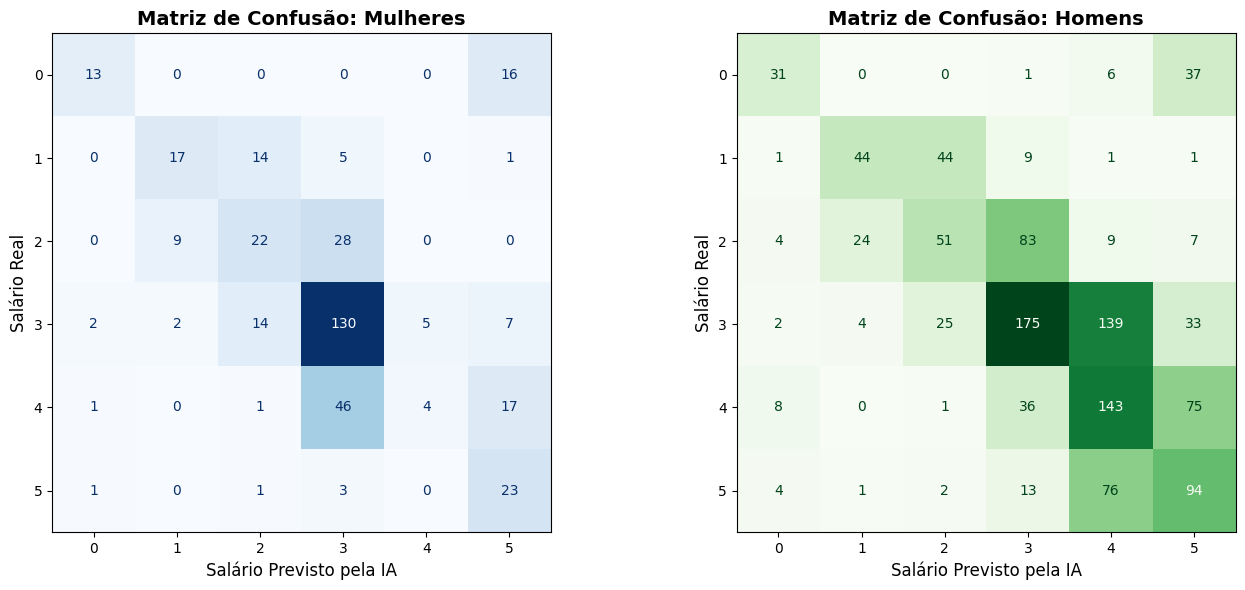

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =========================================================
# 1. SEPARAR OS GRUPOS GERAIS NO X_TEST COMPLETO
# =========================================================
teste_mulheres = X_test[X_test['1.b_genero'] == 1]
teste_homens = X_test[X_test['1.b_genero'] == 0]

# Pegar o "gabarito" (y_true) e a "previsão da IA" (y_pred) para cada grupo
y_true_mulheres = y_test.loc[teste_mulheres.index]
y_pred_mulheres = modelo_tree_completo.predict(teste_mulheres)

y_true_homens = y_test.loc[teste_homens.index]
y_pred_homens = modelo_tree_completo.predict(teste_homens)

# =========================================================
# 2. DESENHAR AS MATRIZES DE CONFUSÃO LADO A LADO
# =========================================================
# Cria uma figura com 2 gráficos (1 linha, 2 colunas)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Gráfico 1: Mulheres (Azul) ---
cm_mulheres = confusion_matrix(y_true_mulheres, y_pred_mulheres)
disp_m = ConfusionMatrixDisplay(confusion_matrix=cm_mulheres)
disp_m.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusão: Mulheres', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Salário Previsto pela IA', fontsize=12)
axes[0].set_ylabel('Salário Real', fontsize=12)

# --- Gráfico 2: Homens (Verde) ---
cm_homens = confusion_matrix(y_true_homens, y_pred_homens)
disp_h = ConfusionMatrixDisplay(confusion_matrix=cm_homens)
disp_h.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Matriz de Confusão: Homens', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Salário Previsto pela IA', fontsize=12)
axes[1].set_ylabel('Salário Real', fontsize=12)

# Ajusta o espaçamento e mostra na tela
plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import f1_score

# Exemplo de como calcular para o grupo de Mulheres Pretas:
y_true_m_pretas = y_test.loc[teste_m_pretas.index]
y_pred_m_pretas = modelo_tree_completo.predict(teste_m_pretas)

f1_m_pretas = f1_score(y_true_m_pretas, y_pred_m_pretas, average='macro')

print(f"📊 F1-Score em Mulheres Pretas: {f1_m_pretas:.2f}")

📊 F1-Score em Mulheres Pretas: 0.39


In [ ]:
plt.figure(figsize=(20,10))
plot_tree(modelo_tree, 
          feature_names=X.columns, 
          class_names=[str(i) for i in ordem_salario], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.show()

NameError: name 'X' is not defined

<Figure size 2000x1000 with 0 Axes>


--- Relatório: Geral ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.00      0.00      0.00        30
           2       0.00      0.00      0.00        45
           3       0.00      0.00      0.00        64
           4       0.29      0.44      0.35       146
           5       0.28      0.15      0.19       171
           6       0.32      0.81      0.46       280
           7       0.00      0.00      0.00       156
           8       0.00      0.00      0.00        64
           9       0.00      0.00      0.00        22
          10       0.00      0.00      0.00        12
          11       0.00      0.00      0.00        17
          12       0.00      0.00      0.00        12

    accuracy                           0.31      1025
   macro avg       0.07      0.11      0.08      1025
weighted avg       0.18      0.31      0.21      1025



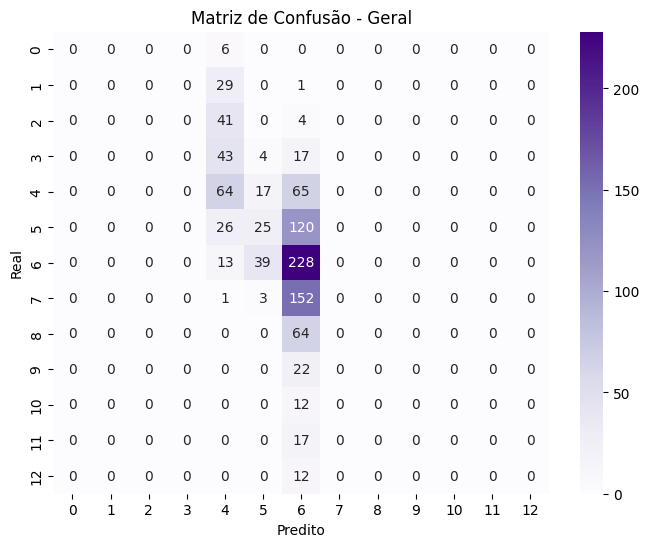


--- Relatório: Apenas Mulheres ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00        13
           2       0.00      0.00      0.00        10
           3       0.00      0.00      0.00        11
           4       0.32      0.53      0.40        36
           5       0.28      0.55      0.37        44
           6       0.48      0.53      0.51        86
           7       0.00      0.00      0.00        28
           8       0.00      0.00      0.00         9
           9       0.00      0.00      0.00         2
          11       0.00      0.00      0.00         1

    accuracy                           0.37       241
   macro avg       0.10      0.15      0.12       241
weighted avg       0.27      0.37      0.31       241



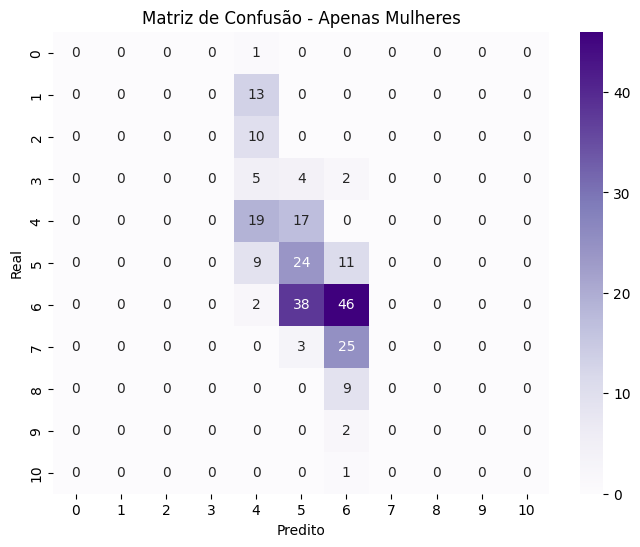


--- Relatório: Apenas Homens ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.00      0.00      0.00        17
           2       0.00      0.00      0.00        35
           3       0.00      0.00      0.00        53
           4       0.27      0.41      0.33       110
           5       0.00      0.00      0.00       126
           6       0.29      0.94      0.45       193
           7       0.00      0.00      0.00       128
           8       0.00      0.00      0.00        55
           9       0.00      0.00      0.00        20
          10       0.00      0.00      0.00        12
          11       0.00      0.00      0.00        16
          12       0.00      0.00      0.00        12

    accuracy                           0.29       782
   macro avg       0.04      0.10      0.06       782
weighted avg       0.11      0.29      0.16       782



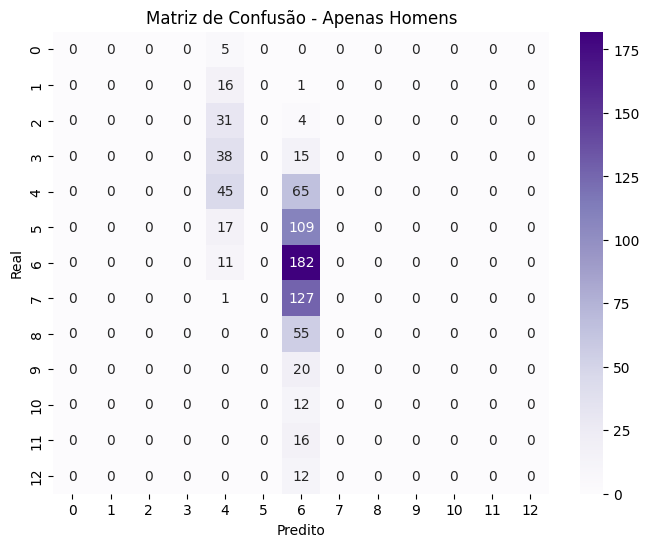


--- Relatório: Apenas Outro ---
              precision    recall  f1-score   support

           5       0.50      1.00      0.67         1
           6       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



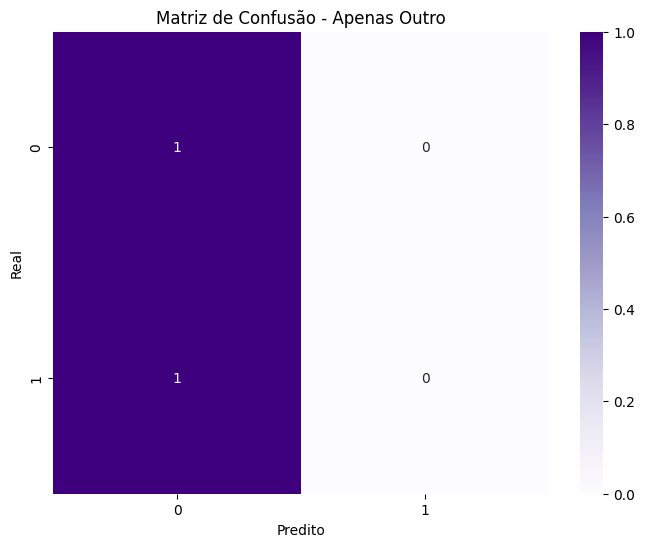

In [ ]:
def auditoria_completa(X_subset, y_subset, titulo):
    y_pred_sub = modelo_tree.predict(X_subset)
    
    print(f"\n--- Relatório: {titulo} ---")
    print(classification_report(y_subset, y_pred_sub, zero_division=0))
    
    # Matriz de Confusão
    cm = confusion_matrix(y_subset, y_pred_sub)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
    plt.title(f'Matriz de Confusão - {titulo}')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()

# Rodar para os 4 casos
auditoria_completa(X_test, y_test, "Geral")
auditoria_completa(teste_mulheres, y_test.loc[teste_mulheres.index], "Apenas Mulheres")
auditoria_completa(teste_homens, y_test.loc[teste_homens.index], "Apenas Homens")
auditoria_completa(teste_outros, y_test.loc[teste_outros.index], "Apenas Outro")

--- RESULTADOS: REGRESSÃO LOGÍSTICA ---

--- Relatório: Geral - Logística ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.00      0.00      0.00        30
           2       0.00      0.00      0.00        45
           3       0.00      0.00      0.00        64
           4       0.29      0.44      0.35       146
           5       0.28      0.15      0.19       171
           6       0.32      0.81      0.46       280
           7       0.00      0.00      0.00       156
           8       0.00      0.00      0.00        64
           9       0.00      0.00      0.00        22
          10       0.00      0.00      0.00        12
          11       0.00      0.00      0.00        17
          12       0.00      0.00      0.00        12

    accuracy                           0.31      1025
   macro avg       0.07      0.11      0.08      1025
weighted avg       0.18      0.31      0.21      1025



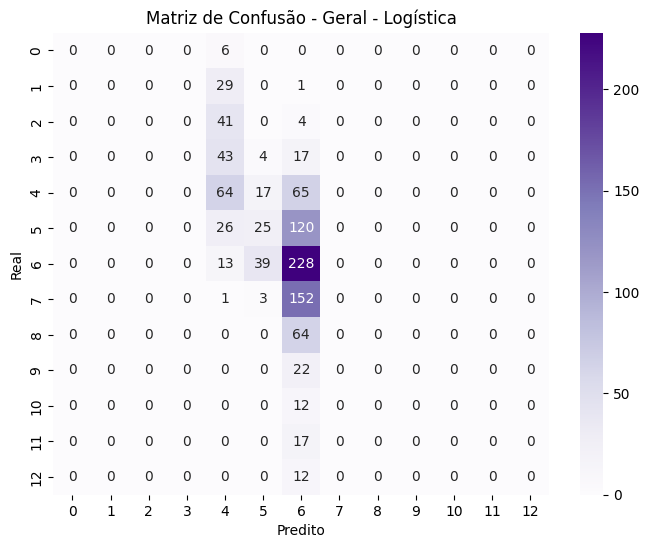


--- Relatório: Mulheres - Logística ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00        13
           2       0.00      0.00      0.00        10
           3       0.00      0.00      0.00        11
           4       0.32      0.53      0.40        36
           5       0.28      0.55      0.37        44
           6       0.48      0.53      0.51        86
           7       0.00      0.00      0.00        28
           8       0.00      0.00      0.00         9
           9       0.00      0.00      0.00         2
          11       0.00      0.00      0.00         1

    accuracy                           0.37       241
   macro avg       0.10      0.15      0.12       241
weighted avg       0.27      0.37      0.31       241



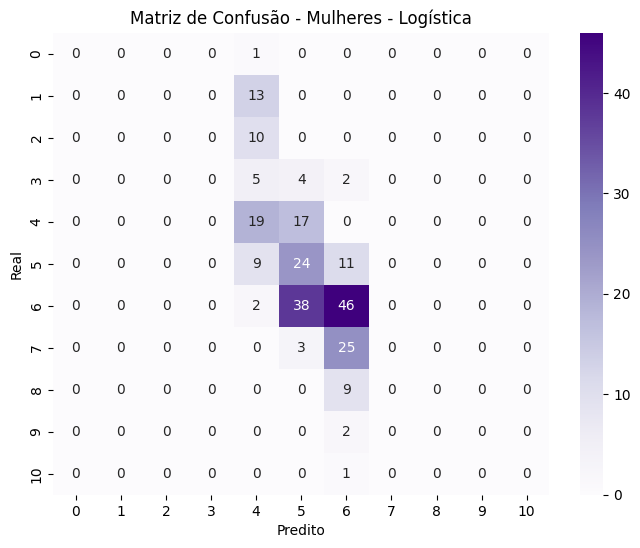


--- Relatório: Homens - Logística ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.00      0.00      0.00        17
           2       0.00      0.00      0.00        35
           3       0.00      0.00      0.00        53
           4       0.27      0.41      0.33       110
           5       0.00      0.00      0.00       126
           6       0.29      0.94      0.45       193
           7       0.00      0.00      0.00       128
           8       0.00      0.00      0.00        55
           9       0.00      0.00      0.00        20
          10       0.00      0.00      0.00        12
          11       0.00      0.00      0.00        16
          12       0.00      0.00      0.00        12

    accuracy                           0.29       782
   macro avg       0.04      0.10      0.06       782
weighted avg       0.11      0.29      0.16       782



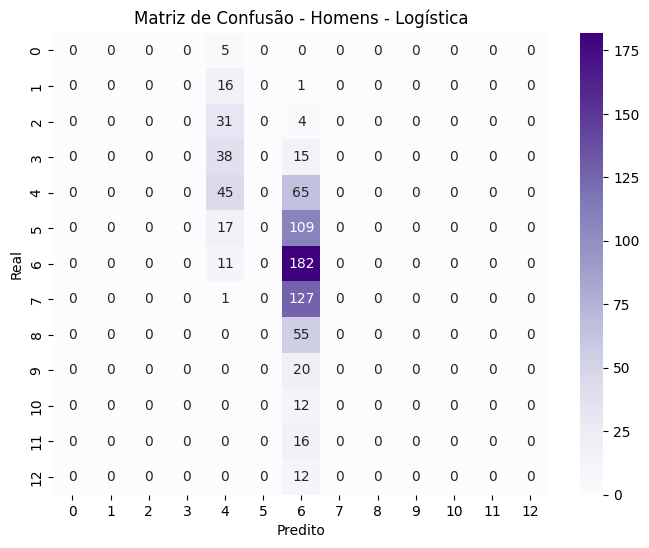

In [ ]:
# Criar o modelo de Regressão Logística

modelo_log = LogisticRegression(max_iter=1000, random_state=42)

# Treinar (usando os mesmos dados de treino da árvore)
modelo_log.fit(X_train, y_train)

# Rodar a auditoria para comparar
print("--- RESULTADOS: REGRESSÃO LOGÍSTICA ---")
auditoria_completa(X_test, y_test, "Geral - Logística")
auditoria_completa(teste_mulheres, y_test.loc[teste_mulheres.index], "Mulheres - Logística")
auditoria_completa(teste_homens, y_test.loc[teste_homens.index], "Homens - Logística")

In [23]:
# Pegamos os coeficientes da primeira classe de salário como exemplo
importancia = modelo_log.coef_[0] 
features = X.columns

for i, v in enumerate(importancia):
    print(f'Variável: {features[i]}, Peso: {v:.4f}')

Variável: Genero_Num, Peso: -0.2672
Variável: Nivel_Num, Peso: -2.1164


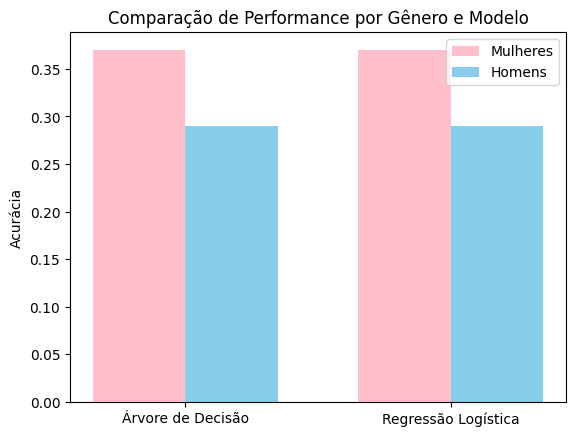

In [24]:
modelos = ['Árvore de Decisão', 'Regressão Logística']
acc_mulheres_total = [0.3693, 0.37] # Substitua pelos seus valores exatos
acc_homens_total = [0.2903, 0.29]   # Substitua pelos seus valores exatos

x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, acc_mulheres_total, width, label='Mulheres', color='pink')
rects2 = ax.bar(x + width/2, acc_homens_total, width, label='Homens', color='skyblue')

ax.set_ylabel('Acurácia')
ax.set_title('Comparação de Performance por Gênero e Modelo')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend()

plt.show()

In [ ]:

# Vamos manter os originais e apenas agrupar para a análise
df_analise = df.copy()

# Criar a coluna numérica de salário para podermos calcular a média

mapa_salario = {label: i for i, label in enumerate(ordem_salario)}
df_analise['Salario_Num'] = df['2.h_faixa_salarial'].map(mapa_salario)

# Calcular a média salarial por gênero (incluindo quem não informou)
comparativo = df_analise.groupby('1.b_genero')['Salario_Num'].mean().sort_values(ascending=False)

print("--- Média de Faixa Salarial por Gênero ---")
print(comparativo)

# Cálculo extra: Percentual de 'Prefiro não informar' em cargos altos
# (Para ver se eles estão no topo da pirâmide)
gestores_omissos = df_analise[(df_analise['2.g_nivel'] == 'Gestão') & 
                              (df_analise['1.b_genero'] == 'Prefiro não informar')].shape[0]


--- Média de Faixa Salarial por Gênero ---
1.b_genero
Outro                   6.500000
Prefiro não informar    6.266667
Masculino               6.112162
Feminino                5.492995
Name: Salario_Num, dtype: float64
